/var/folders/hv/vrlxqgrs1bl41tsgjk0ptb280000gn/T/ipykernel_60953/3062916413.py:38: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


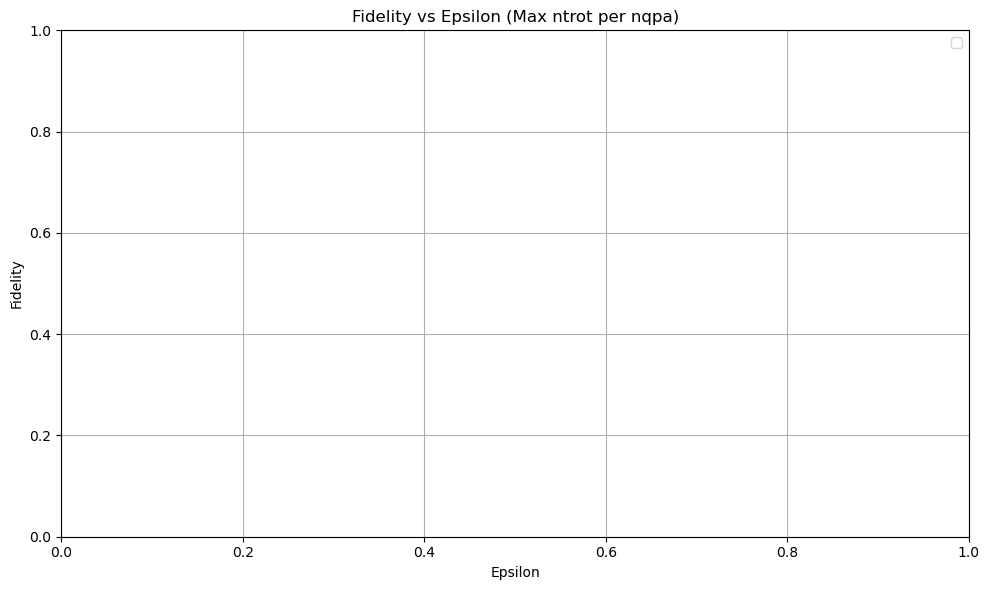

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import re
import glob
import os

# Change into the folder where the fidelity CSVs are stored

# Gather all relevant files
files = glob.glob("*_fidelity.csv")
data_by_nqpa = {}

# For each file, extract nqpa and ntrot from filename
for file in files:
    match = re.search(r'nqpa(\d+)(?:_ntrot(\d+))?', file)
    if match:
        nqpa = int(match.group(1))
        ntrot = int(match.group(2)) if match.group(2) else 0

        # Only keep the one with the max ntrot per nqpa
        if nqpa not in data_by_nqpa or ntrot > data_by_nqpa[nqpa][1]:
            df = pd.read_csv(file)
            data_by_nqpa[nqpa] = (df, ntrot)

# Plot each nqpa’s max-ntrot file
plt.figure(figsize=(10, 6))

for nqpa, (df, ntrot) in sorted(data_by_nqpa.items()):
    y_key = f'QPA_{nqpa}'
    if y_key in df.columns and 'epsilon' in df.columns:
        plt.plot(df['epsilon'], df[y_key], label=f'nqpa={nqpa}, ntrot={ntrot}')
    else:
        print(f"Missing columns in file for nqpa={nqpa}")

plt.xlabel('Epsilon')
plt.ylabel('Fidelity')
plt.title('Fidelity vs Epsilon (Max ntrot per nqpa)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


/var/folders/hv/vrlxqgrs1bl41tsgjk0ptb280000gn/T/ipykernel_60953/193295334.py:27: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colormap = cm.get_cmap('tab10', len(nqpas))  # Use tab10 for distinct base colors


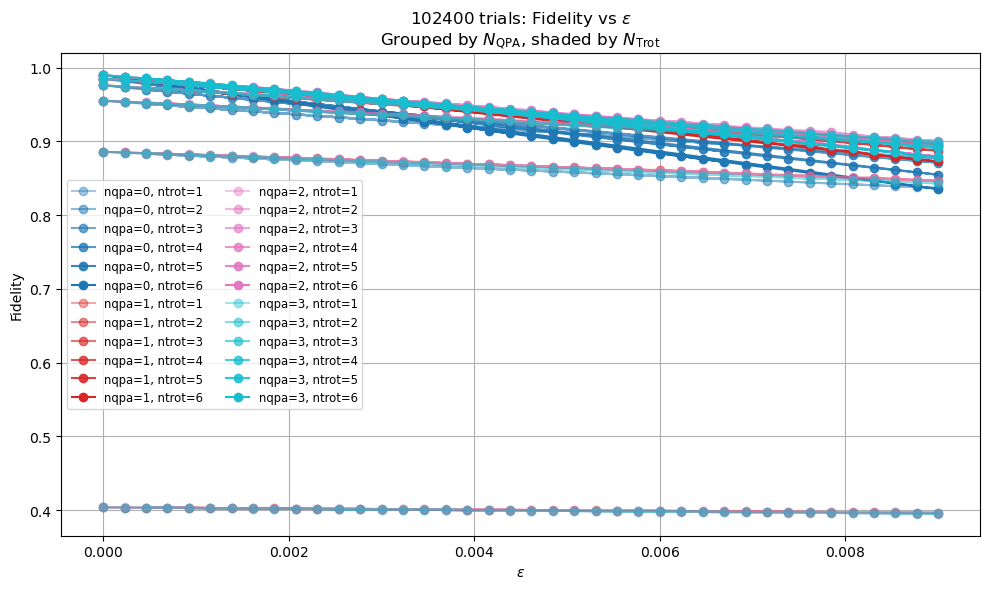

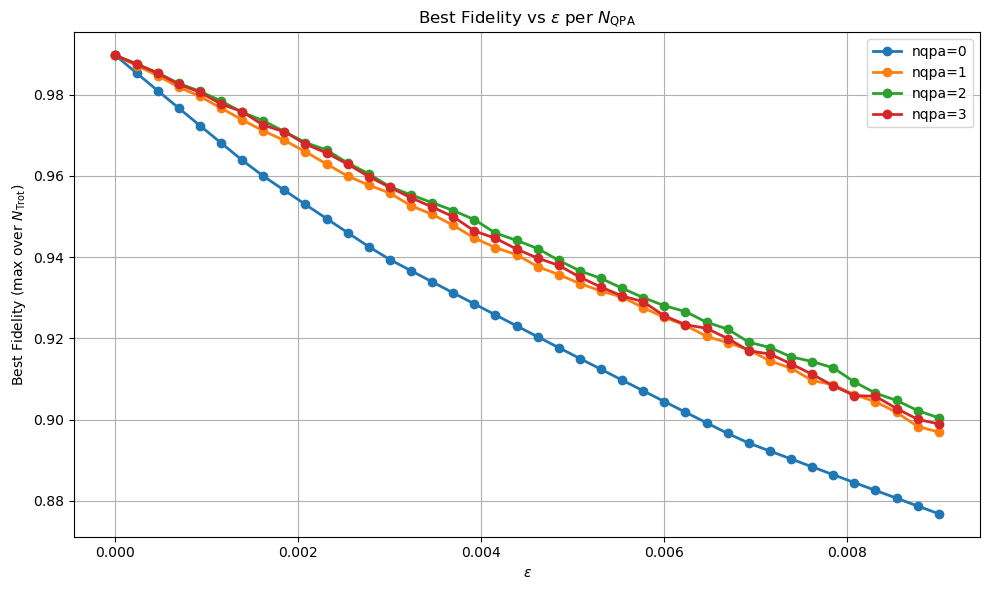

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.colors as mcolors
import re
import glob
import os

plt.figure(figsize=(10, 6))

# Look for all combined output files
files = sorted(glob.glob("estimation_k3_shots102400_eps0.0-0.009_s40_t1/*_combined.csv"))

# Collect data grouped by nqpa
grouped = {}
for file in files:
    match = re.search(r'nqpa(\d+)_ntrot(\d+)', file)
    if match:
        nqpa = int(match.group(1))
        ntrot = int(match.group(2))
        grouped.setdefault(nqpa, []).append((ntrot, file))
    else:
        print(f"Skipping {file} — filename pattern not matched")

# Assign a color per nqpa
nqpas = sorted(grouped.keys())
colormap = cm.get_cmap('tab10', len(nqpas))  # Use tab10 for distinct base colors

for idx, nqpa in enumerate(nqpas):
    base_color = colormap(idx)
    norm = mcolors.Normalize(
        vmin=min(ntrot for ntrot, _ in grouped[nqpa]),
        vmax=max(ntrot for ntrot, _ in grouped[nqpa])
    )

    for ntrot, file in sorted(grouped[nqpa]):
        df = pd.read_csv(file)
        # We don’t know the exact column name, so we extract the QPA column:
        qpa_col = [col for col in df.columns if col.startswith('QPA_')]
        if qpa_col and 'epsilon' in df.columns:
            y_key = qpa_col[0]
            alpha = 0.4 + 0.6 * norm(ntrot)  # more ntrot = darker
            color = mcolors.to_rgba(base_color, alpha=alpha)
            plt.plot(df['epsilon'], df[y_key], marker='o',
                     color=color,
                     label=f'nqpa={nqpa}, ntrot={ntrot}')
        else:
            print(f"Skipping {file} — missing epsilon or QPA column")

plt.xlabel('$\epsilon$')
plt.ylabel('Fidelity')
plt.title('102400 trials: Fidelity vs $\epsilon$\nGrouped by $N_\\mathrm{QPA}$, shaded by $N_\\mathrm{Trot}$')
plt.grid(True)
plt.tight_layout()
plt.legend(ncol=2, fontsize='small')
plt.show()


plt.figure(figsize=(10, 6))

for idx, nqpa in enumerate(nqpas):
    eps_to_best_fid = {}

    for _, file in grouped[nqpa]:
        df = pd.read_csv(file)
        qpa_col = [col for col in df.columns if col.startswith('QPA_')]
        if not qpa_col or 'epsilon' not in df.columns:
            continue

        y_key = qpa_col[0]
        for eps, fid in zip(df['epsilon'], df[y_key]):
            eps_to_best_fid[eps] = max(eps_to_best_fid.get(eps, -1), fid)

    # Sort by epsilon
    eps_sorted = sorted(eps_to_best_fid.keys())
    fids_sorted = [eps_to_best_fid[eps] for eps in eps_sorted]

    plt.plot(eps_sorted, fids_sorted, marker='o', label=f'nqpa={nqpa}', linewidth=2)

plt.xlabel('$\epsilon$')
plt.ylabel('Best Fidelity (max over $N_\\mathrm{Trot}$)')
plt.title('Best Fidelity vs $\epsilon$ per $N_\\mathrm{QPA}$')
plt.grid(True)
plt.tight_layout()
plt.legend()
plt.show()

/var/folders/hv/vrlxqgrs1bl41tsgjk0ptb280000gn/T/ipykernel_60953/621105217.py:19: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colormap = cm.get_cmap('tab10', len(nqpas))  # Use tab10 for distinct base colors


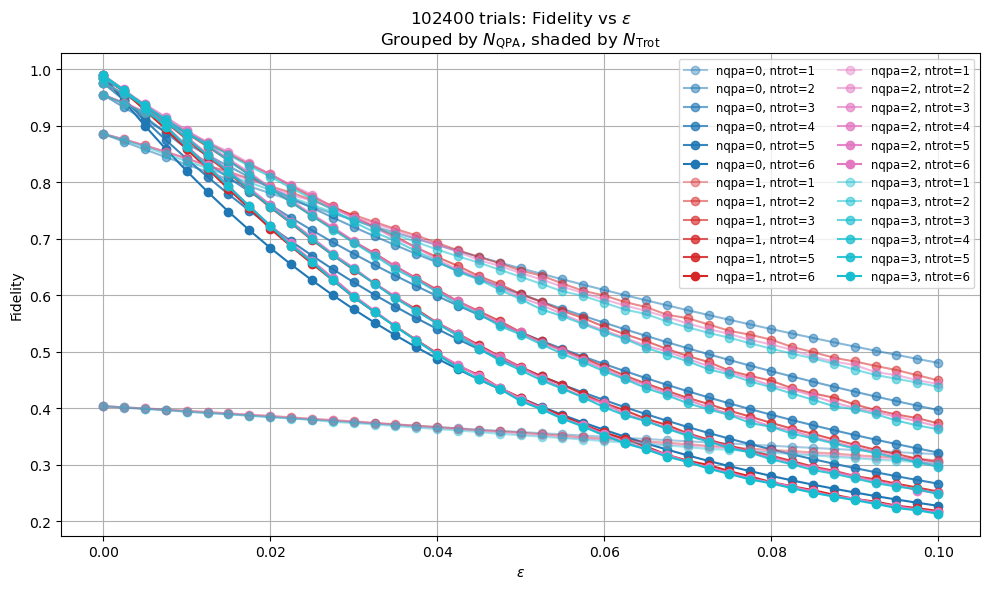

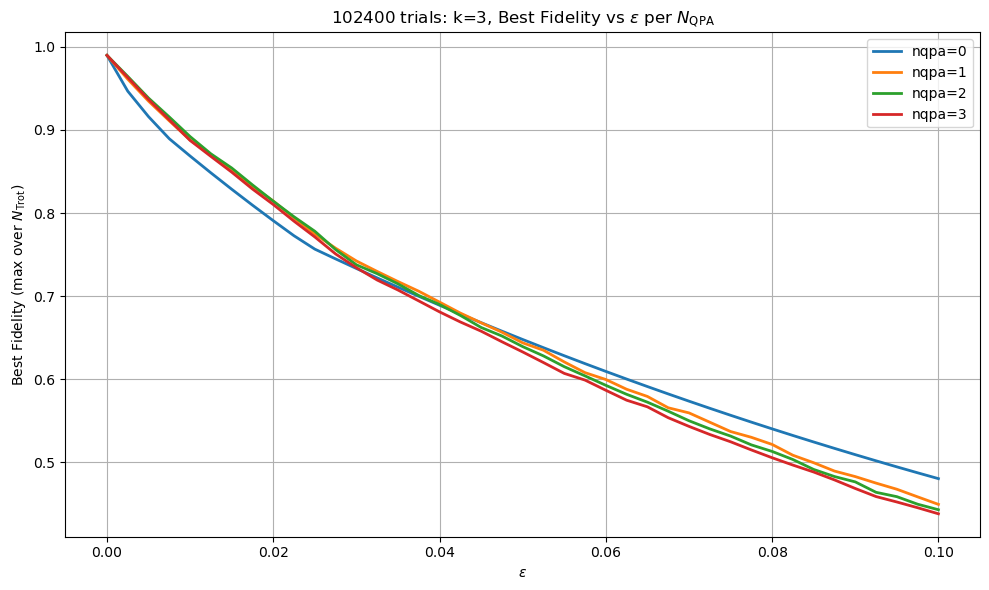

In [7]:
plt.figure(figsize=(10, 6))

# Look for all combined output files
files = sorted(glob.glob("estimation_k3_shots102400_eps0.0-0.1_s41_t1.0_J1.0_h1.0/*_combined.csv"))

# Collect data grouped by nqpa
grouped = {}
for file in files:
    match = re.search(r'nqpa(\d+)_ntrot(\d+)', file)
    if match:
        nqpa = int(match.group(1))
        ntrot = int(match.group(2))
        grouped.setdefault(nqpa, []).append((ntrot, file))
    else:
        print(f"Skipping {file} — filename pattern not matched")

# Assign a color per nqpa
nqpas = sorted(grouped.keys())
colormap = cm.get_cmap('tab10', len(nqpas))  # Use tab10 for distinct base colors

for idx, nqpa in enumerate(nqpas):
    base_color = colormap(idx)
    norm = mcolors.Normalize(
        vmin=min(ntrot for ntrot, _ in grouped[nqpa]),
        vmax=max(ntrot for ntrot, _ in grouped[nqpa])
    )

    for ntrot, file in sorted(grouped[nqpa]):
        df = pd.read_csv(file)
        # We don’t know the exact column name, so we extract the QPA column:
        qpa_col = [col for col in df.columns if col.startswith('QPA_')]
        if qpa_col and 'epsilon' in df.columns:
            y_key = qpa_col[0]
            alpha = 0.4 + 0.6 * norm(ntrot)  # more ntrot = darker
            color = mcolors.to_rgba(base_color, alpha=alpha)
            plt.plot(df['epsilon'], df[y_key], marker='o',
                     color=color,
                     label=f'nqpa={nqpa}, ntrot={ntrot}')
        else:
            print(f"Skipping {file} — missing epsilon or QPA column")

plt.xlabel('$\epsilon$')
plt.ylabel('Fidelity')
plt.title('102400 trials: Fidelity vs $\epsilon$\nGrouped by $N_\\mathrm{QPA}$, shaded by $N_\\mathrm{Trot}$')
plt.grid(True)
plt.tight_layout()
plt.legend(ncol=2, fontsize='small')
plt.show()


plt.figure(figsize=(10, 6))

for idx, nqpa in enumerate(nqpas):
    eps_to_best_fid = {}

    for _, file in grouped[nqpa]:
        df = pd.read_csv(file)
        qpa_col = [col for col in df.columns if col.startswith('QPA_')]
        if not qpa_col or 'epsilon' not in df.columns:
            continue

        y_key = qpa_col[0]
        for eps, fid in zip(df['epsilon'], df[y_key]):
            eps_to_best_fid[eps] = max(eps_to_best_fid.get(eps, -1), fid)

    # Sort by epsilon
    eps_sorted = sorted(eps_to_best_fid.keys())
    fids_sorted = [eps_to_best_fid[eps] for eps in eps_sorted]

    plt.plot(eps_sorted, fids_sorted, label=f'nqpa={nqpa}', linewidth=2)

plt.xlabel('$\epsilon$')
plt.ylabel('Best Fidelity (max over $N_\\mathrm{Trot}$)')
plt.title('102400 trials: k=3, Best Fidelity vs $\epsilon$ per $N_\\mathrm{QPA}$')
plt.grid(True)
plt.tight_layout()
plt.legend()
plt.show()

/var/folders/hv/vrlxqgrs1bl41tsgjk0ptb280000gn/T/ipykernel_47088/2006886776.py:19: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colormap = cm.get_cmap('tab10', len(nqpas))  # Use tab10 for distinct base colors


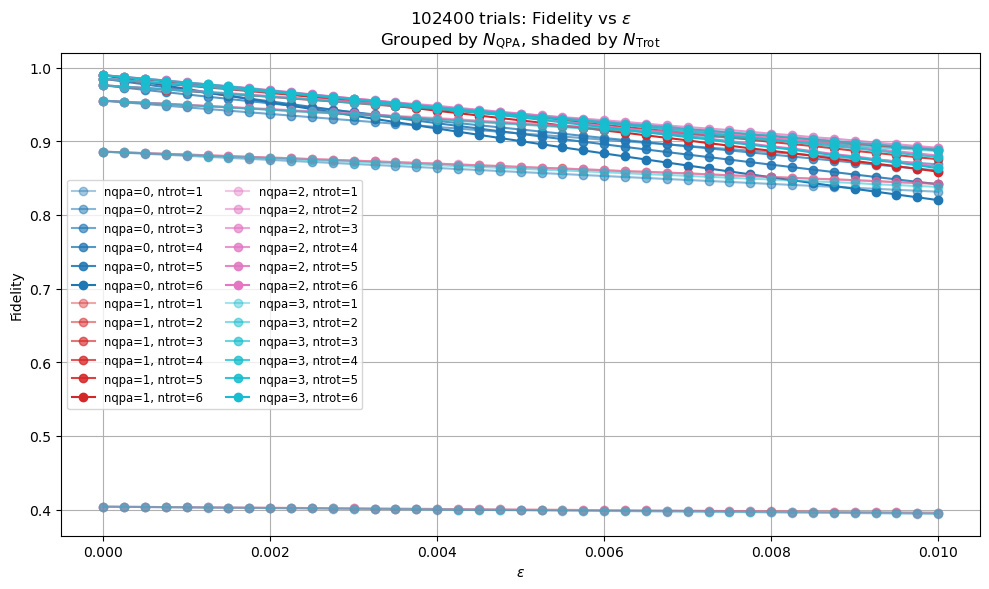

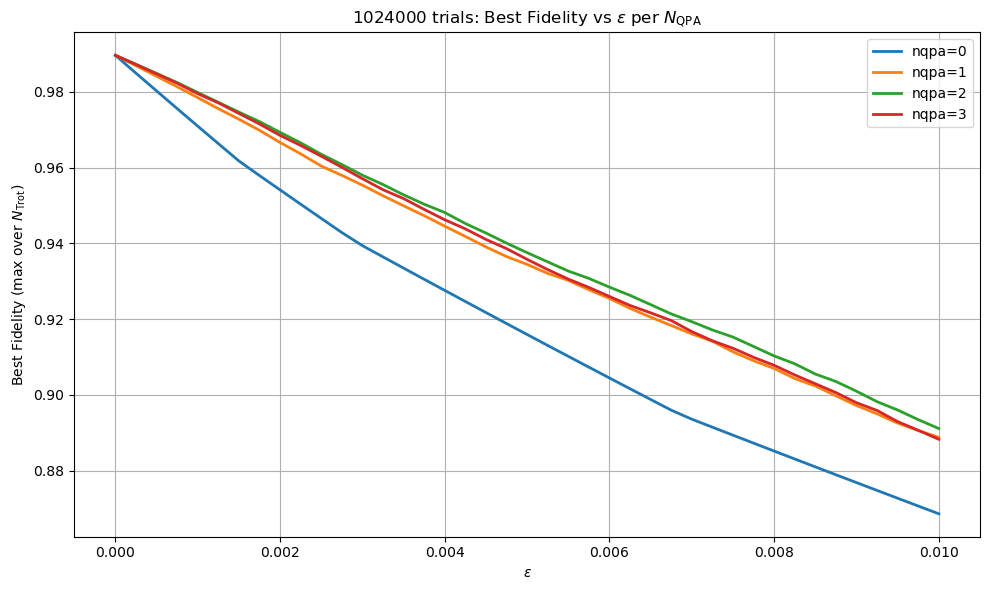

In [6]:
plt.figure(figsize=(10, 6))

# Look for all combined output files
files = sorted(glob.glob("estimation_k3_shots1024000_eps0.0-0.01_s41_t1.0_J1.0_h1.0/*_combined.csv"))

# Collect data grouped by nqpa
grouped = {}
for file in files:
    match = re.search(r'nqpa(\d+)_ntrot(\d+)', file)
    if match:
        nqpa = int(match.group(1))
        ntrot = int(match.group(2))
        grouped.setdefault(nqpa, []).append((ntrot, file))
    else:
        print(f"Skipping {file} — filename pattern not matched")

# Assign a color per nqpa
nqpas = sorted(grouped.keys())
colormap = cm.get_cmap('tab10', len(nqpas))  # Use tab10 for distinct base colors

for idx, nqpa in enumerate(nqpas):
    base_color = colormap(idx)
    norm = mcolors.Normalize(
        vmin=min(ntrot for ntrot, _ in grouped[nqpa]),
        vmax=max(ntrot for ntrot, _ in grouped[nqpa])
    )

    for ntrot, file in sorted(grouped[nqpa]):
        df = pd.read_csv(file)
        # We don’t know the exact column name, so we extract the QPA column:
        qpa_col = [col for col in df.columns if col.startswith('QPA_')]
        if qpa_col and 'epsilon' in df.columns:
            y_key = qpa_col[0]
            alpha = 0.4 + 0.6 * norm(ntrot)  # more ntrot = darker
            color = mcolors.to_rgba(base_color, alpha=alpha)
            plt.plot(df['epsilon'], df[y_key], marker='o',
                     color=color,
                     label=f'nqpa={nqpa}, ntrot={ntrot}')
        else:
            print(f"Skipping {file} — missing epsilon or QPA column")

plt.xlabel('$\epsilon$')
plt.ylabel('Fidelity')
plt.title('102400 trials: Fidelity vs $\epsilon$\nGrouped by $N_\\mathrm{QPA}$, shaded by $N_\\mathrm{Trot}$')
plt.grid(True)
plt.tight_layout()
plt.legend(ncol=2, fontsize='small')
plt.show()


plt.figure(figsize=(10, 6))

for idx, nqpa in enumerate(nqpas):
    eps_to_best_fid = {}

    for _, file in grouped[nqpa]:
        df = pd.read_csv(file)
        qpa_col = [col for col in df.columns if col.startswith('QPA_')]
        if not qpa_col or 'epsilon' not in df.columns:
            continue

        y_key = qpa_col[0]
        for eps, fid in zip(df['epsilon'], df[y_key]):
            eps_to_best_fid[eps] = max(eps_to_best_fid.get(eps, -1), fid)

    # Sort by epsilon
    eps_sorted = sorted(eps_to_best_fid.keys())
    fids_sorted = [eps_to_best_fid[eps] for eps in eps_sorted]

    plt.plot(eps_sorted, fids_sorted, label=f'nqpa={nqpa}', linewidth=2)

plt.xlabel('$\epsilon$')
plt.ylabel('Best Fidelity (max over $N_\\mathrm{Trot}$)')
plt.title('1024000 trials: Best Fidelity vs $\epsilon$ per $N_\\mathrm{QPA}$')
plt.grid(True)
plt.tight_layout()
plt.legend()
plt.show()

/var/folders/hv/vrlxqgrs1bl41tsgjk0ptb280000gn/T/ipykernel_60953/3635339388.py:19: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colormap = cm.get_cmap('tab10', len(nqpas))  # Use tab10 for distinct base colors


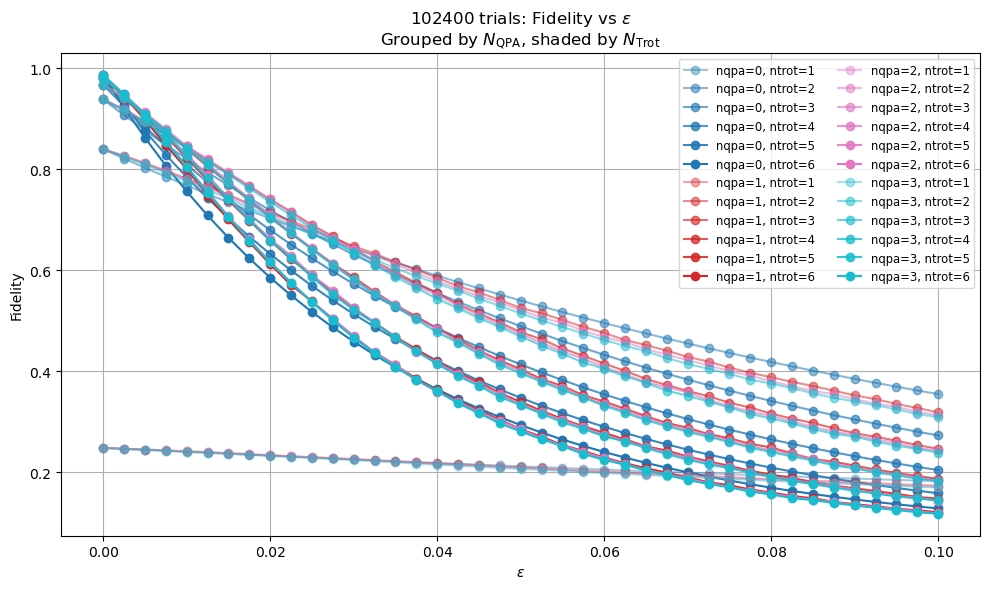

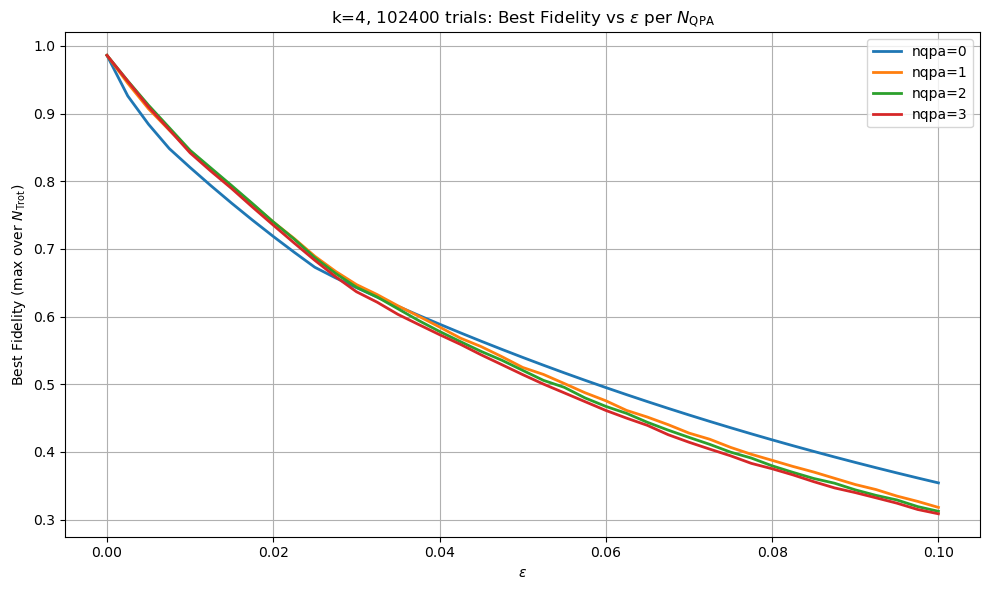

In [6]:
plt.figure(figsize=(10, 6))

# Look for all combined output files
files = sorted(glob.glob("estimation_k4_shots102400_eps0.0-0.1_s41_t1.0_J1.0_h1.0/*_combined.csv"))

# Collect data grouped by nqpa
grouped = {}
for file in files:
    match = re.search(r'nqpa(\d+)_ntrot(\d+)', file)
    if match:
        nqpa = int(match.group(1))
        ntrot = int(match.group(2))
        grouped.setdefault(nqpa, []).append((ntrot, file))
    else:
        print(f"Skipping {file} — filename pattern not matched")

# Assign a color per nqpa
nqpas = sorted(grouped.keys())
colormap = cm.get_cmap('tab10', len(nqpas))  # Use tab10 for distinct base colors

for idx, nqpa in enumerate(nqpas):
    base_color = colormap(idx)
    norm = mcolors.Normalize(
        vmin=min(ntrot for ntrot, _ in grouped[nqpa]),
        vmax=max(ntrot for ntrot, _ in grouped[nqpa])
    )

    for ntrot, file in sorted(grouped[nqpa]):
        df = pd.read_csv(file)
        # We don’t know the exact column name, so we extract the QPA column:
        qpa_col = [col for col in df.columns if col.startswith('QPA_')]
        if qpa_col and 'epsilon' in df.columns:
            y_key = qpa_col[0]
            alpha = 0.4 + 0.6 * norm(ntrot)  # more ntrot = darker
            color = mcolors.to_rgba(base_color, alpha=alpha)
            plt.plot(df['epsilon'], df[y_key], marker='o',
                     color=color,
                     label=f'nqpa={nqpa}, ntrot={ntrot}')
        else:
            print(f"Skipping {file} — missing epsilon or QPA column")

plt.xlabel('$\epsilon$')
plt.ylabel('Fidelity')
plt.title('102400 trials: Fidelity vs $\epsilon$\nGrouped by $N_\\mathrm{QPA}$, shaded by $N_\\mathrm{Trot}$')
plt.grid(True)
plt.tight_layout()
plt.legend(ncol=2, fontsize='small')
plt.show()


plt.figure(figsize=(10, 6))

for idx, nqpa in enumerate(nqpas):
    eps_to_best_fid = {}

    for _, file in grouped[nqpa]:
        df = pd.read_csv(file)
        qpa_col = [col for col in df.columns if col.startswith('QPA_')]
        if not qpa_col or 'epsilon' not in df.columns:
            continue

        y_key = qpa_col[0]
        for eps, fid in zip(df['epsilon'], df[y_key]):
            eps_to_best_fid[eps] = max(eps_to_best_fid.get(eps, -1), fid)

    # Sort by epsilon
    eps_sorted = sorted(eps_to_best_fid.keys())
    fids_sorted = [eps_to_best_fid[eps] for eps in eps_sorted]

    plt.plot(eps_sorted, fids_sorted, label=f'nqpa={nqpa}', linewidth=2)

plt.xlabel('$\epsilon$')
plt.ylabel('Best Fidelity (max over $N_\\mathrm{Trot}$)')
plt.title('k=4, 102400 trials: Best Fidelity vs $\epsilon$ per $N_\\mathrm{QPA}$')
plt.grid(True)
plt.tight_layout()
plt.legend()
plt.show()